In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import random
import textwrap

The dataset is inspired by the TinyStories project (https://github.com/OrhanKahveci/TinyStories).

In [3]:
africa_galore = pd.read_json(
    "https://storage.googleapis.com/dm-educational/assets/ai_foundations/africa_galore.json"
)
dataset = africa_galore["description"]
print(f"The dataset consists of {dataset.shape[0]} paragraphs.")

The dataset consists of 232 paragraphs.


In [4]:
# Check out some sample paragraphs
for i in random.sample(range(dataset.shape[0]), 3):
    print("\n".join(textwrap.wrap(dataset[i], width=80)))

Kenyan chai is a milky, spiced tea enjoyed commonly in East Africa. Black tea
leaves are boiled with water, milk, and sugar, often along with spices such as
ginger, cinnamon, or cardamom (similar to masala chai). The result is a hot,
creamy tea with a comforting aroma and a balance of sweet and spicy flavors.
It's typically served in mugs and enjoyed at breakfast or any time of day as a
soothing drink.
The Dakar waterfront was buzzing with activity as the sun began to set. From a
nearby restaurant, the vibrant sounds of Mbalax music spilled out, the
distinctive vocals of Youssou N'Dour soaring over the complex percussion and the
hypnotic basslines. A group of friends, gathered for an evening meal, swayed to
the music, their faces lit up with smiles. The Mbalax rhythms, a blend of
traditional Senegalese music and modern influences, created an atmosphere of
celebration and joy, a vibrant expression of Senegalese culture.
Saka-saka, also known as cassava leaves stew or pondu, is a staple 

In [5]:
# Combine all paragraphs into a single text
all_text = " ".join(dataset.tolist())
print(f"The combined text has {len(all_text)} characters.")

The combined text has 117578 characters.


In [6]:
# View first 500 characters
print("\n".join(textwrap.wrap(all_text[:500], width=80)))

The Lagos air was thick with humidity, but the energy in the club was electric.
The band launched into a hypnotic Afrobeat groove, the drums pounding out a
complex polyrhythm, the horns blaring a soaring melody, and the bass laying down
a deep, funky foundation. A woman named Imani moved effortlessly to the music,
her body swaying in time with the rhythm. The music seemed to flow through her,
a powerful current of energy and joy. All around her, people were dancing,
singing, and clapping, caught


In [7]:
# Since we have combined all paragraphs into a single text, we can now create n-grams from it.
# But first, tokenize the text into words.
tokens = all_text.split()
print(f"The text has {len(tokens)} tokens.")
print("First 20 tokens:", tokens[:20])

The text has 19064 tokens.
First 20 tokens: ['The', 'Lagos', 'air', 'was', 'thick', 'with', 'humidity,', 'but', 'the', 'energy', 'in', 'the', 'club', 'was', 'electric.', 'The', 'band', 'launched', 'into', 'a']


Context:

* N-grams are contiguous sequences of n items from a given sample of text or speech. For example, in the sentence "The cat sat on the mat", the 2-grams (bigrams) are "The cat", "cat sat", "sat on", "on the", "the mat" and 3-grams (trigrams) are "The cat sat", "cat sat on", "sat on the", "on the mat". They can exist at the level of characters, words, or even phonemes.
The context window of n-grams refers to the number of preceding items (words, characters, etc.) that are considered when predicting the next item in a sequence. For instance, in a bigram model (n=2), the context window is 1, meaning that only the immediately preceding word is used to predict the next word. In a trigram model (n=3), the context window is 2, so the two preceding words are used for prediction.

History of n-grams:
* The concept of n-grams has been around for a long time, with early applications in information retrieval and computational linguistics dating back to the 1950s and 1960s. They form the basis of language modeling based on [Markov chains](https://en.wikipedia.org/wiki/Markov_chain), where the probability of a word depends on the previous n-1 words.

* Famous linguists and computer scientists like Claude Shannon and Noam Chomsky have contributed to the development of n-gram models. Shannon's work on information theory laid the groundwork for understanding how to model language statistically, while Chomsky's theories on syntax and grammar influenced the way we think about language structure.

* British linguist J.R. Firth is often credited with popularizing the use of n-grams in computational linguistics. His famous quote, "You shall know a word by the company it keeps," highlights the importance of context in understanding language, which is a fundamental principle behind n-gram models. His work, together with that of Zellig Harris, helped establish the foundation for distributional semantics ie the study of word meaning based on context, which is closely related to n-gram analysis.

In [8]:
# Create n-grams
def create_ngrams(tokens, n):
    ngrams = {}
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        if ngram in ngrams:
            ngrams[ngram] += 1
        else:
            ngrams[ngram] = 1
    return ngrams

# Create and display bigrams
bigrams = create_ngrams(tokens, 2)
sorted_bigrams = sorted(bigrams.items(), key=lambda x: x[1], reverse=True)
print("Top 10 bigrams:")
for ngram, count in sorted_bigrams[:10]:
    print(f"{ngram}: {count}")
# Create and display trigrams
trigrams = create_ngrams(tokens, 3)
sorted_trigrams = sorted(trigrams.items(), key=lambda x: x[1], reverse=True)
print("Top 10 trigrams:")
for ngram, count in sorted_trigrams[:10]:
    print(f"{ngram}: {count}")

Top 10 bigrams:
('is', 'a'): 144
('of', 'the'): 100
('and', 'the'): 69
('in', 'the'): 61
('with', 'a'): 60
('in', 'a'): 55
('and', 'a'): 50
('to', 'the'): 42
('was', 'a'): 39
('It', 'is'): 33
Top 10 trigrams:
('went', 'looking', 'for'): 32
('a', 'symbol', 'of'): 18
('was', 'hungry', 'so'): 18
('The', 'result', 'is'): 17
('looking', 'for', 'a'): 17
('she', 'went', 'looking'): 16
('he', 'went', 'looking'): 16
('result', 'is', 'a'): 15
('so', 'he', 'went'): 14
('so', 'she', 'went'): 14


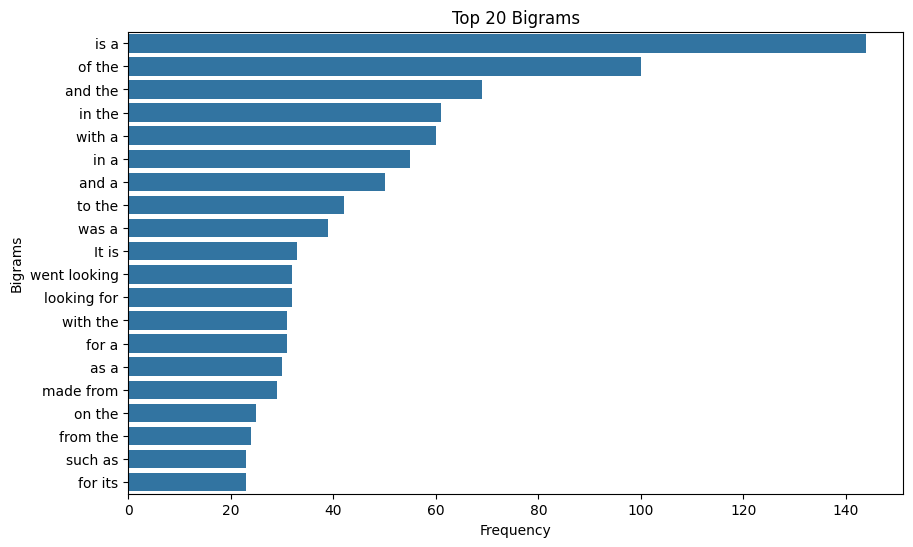

In [9]:
# Visualize bigram frequencies
bigram_df = pd.DataFrame(sorted_bigrams, columns=["bigram", "count"]).head(20)
# Convert tuple bigrams to readable strings for plotting (avoids MultiIndex issues)
bigram_df["bigram"] = bigram_df["bigram"].apply(lambda t: " ".join(t) if isinstance(t, (list, tuple)) else str(t))
plt.figure(figsize=(10, 6))
sns.barplot(x="count", y="bigram", data=bigram_df, order=bigram_df.sort_values("count", ascending=False)["bigram"])
plt.title("Top 20 Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

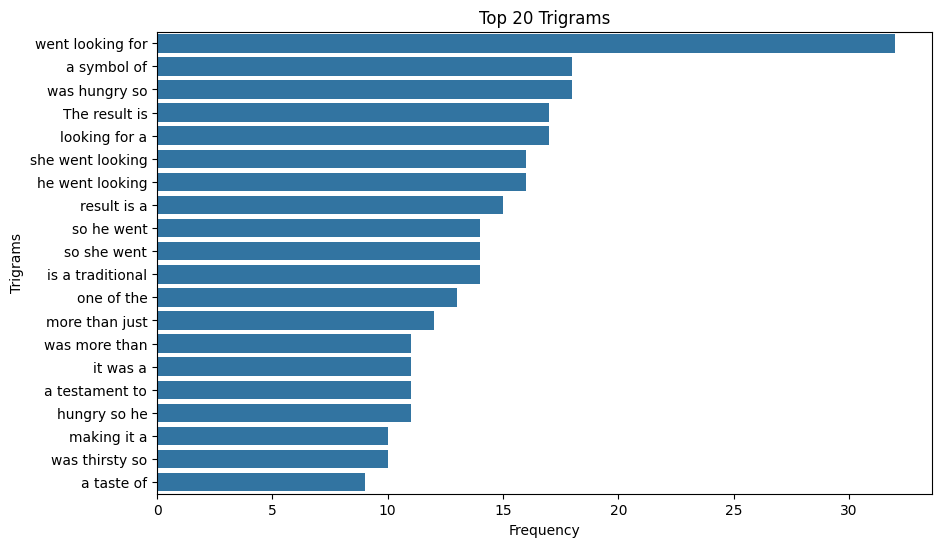

In [10]:
# Visualize trigram frequencies
trigram_df = pd.DataFrame(sorted_trigrams, columns=["trigram", "count"]).head(20)
# Convert tuple trigrams to readable strings for plotting (avoids MultiIndex issues)
trigram_df["trigram"] = trigram_df["trigram"].apply(lambda t: " ".join(t) if isinstance(t, (list, tuple)) else str(t))
plt.figure(figsize=(10, 6))
sns.barplot(x="count", y="trigram", data=trigram_df, order=trigram_df.sort_values("count", ascending=False)["trigram"])
plt.title("Top 20 Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.show()

Predicting the next word using n-grams:
* N-gram models predict the next word in a sequence based on the previous n-1 words. For example, in a bigram model, the probability of the next word is determined solely by the immediately preceding word. In a trigram model, the two preceding words are used to predict the next word. This is typically done by calculating the frequency of word sequences in a training corpus and using these frequencies to estimate probabilities. 

* This concept is borrowed from Markov chains, where the future state (next word) depends only on the current state (previous n-1 words) and not on the sequence of events that preceded it. N-gram models are widely used in various applications, including speech recognition, text prediction, and machine translation.

* At the core of it, is conditional probability which states that the probability of an event (next word) depends on the occurrence of a previous event (previous n-1 words). In n-gram models, this is expressed as:
$P(w_n | w_{n-1}, w_{n-2}, ..., w_{n-(k-1)})$
where $P(w_n | w_{n-1}, w_{n-2}, ..., w_{n-(k-1)})$ is the probability of the next word $w_n$ given the previous k-1 words $w_{n-1}, w_{n-2}, ..., w_{n-(k-1)}$ 

For example, $P(rice | eat, I)$ is the probability of the word "rice" occurring after the words "I eat" in a trigram model (k=3). In bigram model (k=2), it would be $P(rice | eat)$ which is the probability of "rice" occurring after "eat".

* This formula captures the essence of how n-gram models use context to predict the next word in a sequence. The probabilities are typically estimated from the frequency counts of n-grams in a large corpus of text. The higher the frequency of a particular n-gram, the higher the probability assigned to that sequence, making it more likely to be predicted as the next word.

In [11]:
# Probability of next word given previous word using bigrams
def bigram_probability(bigram, bigrams_dict):
    first_word = bigram[0]
    total_count = sum(count for ngram, count in bigrams_dict.items() if ngram[0] == first_word)
    bigram_count = bigrams_dict.get(bigram, 0)
    if total_count == 0:
        return 0
    return bigram_count / total_count
sample_bigram = ('the', 'continent')
prob = bigram_probability(sample_bigram, bigrams)
print(f"Probability of '{sample_bigram[1]}' given '{sample_bigram[0]}': {prob:.4f}")

Probability of 'continent' given 'the': 0.0000


In [12]:
# Probability of next word given previous two words using trigrams
def trigram_probability(trigram, trigrams_dict):
    first_two_words = trigram[:2]
    total_count = sum(count for ngram, count in trigrams_dict.items() if ngram[:2] == first_two_words)
    trigram_count = trigrams_dict.get(trigram, 0)
    if total_count == 0:
        return 0
    return trigram_count / total_count
sample_trigram = ('the', 'continent', 'of')
prob = trigram_probability(sample_trigram, trigrams)
print(f"Probability of '{sample_trigram[2]}' given '{sample_trigram[0]} {sample_trigram[1]}': {prob:.4f}")

Probability of 'of' given 'the continent': 0.0000


In [15]:
# Now we will try with words present in the text
sample_bigram = ('is', 'a')
prob = bigram_probability(sample_bigram, bigrams)
print(f"Probability of '{sample_bigram[1]}' given '{sample_bigram[0]}': {prob:.4f}")

Probability of 'a' given 'is': 0.3956


In [16]:
sample_trigram = ('is', 'a', 'continent')
prob = trigram_probability(sample_trigram, trigrams)
print(f"Probability of '{sample_trigram[2]}' given '{sample_trigram[0]} {sample_trigram[1]}': {prob:.4f}")

Probability of 'continent' given 'is a': 0.0000


In [17]:
# Now generate a sequence of words using bigrams
def generate_text_bigrams(start_word, bigrams_dict, length=10):
    current_word = start_word
    output = [current_word]
    for _ in range(length - 1):
        candidates = {ngram[1]: count for ngram, count in bigrams_dict.items() if ngram[0] == current_word}
        if not candidates:
            break
        next_word = max(candidates, key=candidates.get)
        output.append(next_word)
        current_word = next_word
    return " ".join(output)
generated_text = generate_text_bigrams("Africa", bigrams, length=15)
print("Generated text using bigrams:")
print(generated_text)

Generated text using bigrams:
Africa and the rich cultural heritage and the rich cultural heritage and the rich cultural


In [18]:
# Now generate a sequence of words using trigrams
def generate_text_trigrams(start_words, trigrams_dict, length=10):
    current_words = list(start_words)
    output = current_words.copy()
    for _ in range(length - 2):
        candidates = {ngram[2]: count for ngram, count in trigrams_dict.items() if ngram[:2] == tuple(current_words[-2:])}
        if not candidates:
            break
        next_word = max(candidates, key=candidates.get)
        output.append(next_word)
        current_words.append(next_word)
    return " ".join(output)
generated_text = generate_text_trigrams(("Africa", "is"), trigrams, length=15)
print("Generated text using trigrams:")
print(generated_text)

Generated text using trigrams:
Africa is also a critical water tower for the villagers, who lived in a rich
